## 1. Importar Librerías

In [33]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Configuración
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Semilla para reproducibilidad
semilla = 7
np.random.seed(semilla)

print("✅ Librerías importadas exitosamente")

✅ Librerías importadas exitosamente


## 2. Generación de Datos Sintéticos

Crearemos un dataset de usuarios con las siguientes características:
- **Experiencia**: Nivel de experiencia (Principiante, Intermedio, Avanzado)
- **Objetivo**: Meta principal (Pérdida de peso, Ganar músculo, Resistencia, Salud general)
- **Equipo**: Disponibilidad de equipo (Gimnasio completo, Casa con equipo, Solo peso corporal)
- **Tiempo**: Minutos disponibles por sesión (15-120 min)
- **Frecuencia**: Días por semana (2-7 días)
- **Edad**: Rango de edad (18-65 años)
- **Restricciones**: Lesiones o limitaciones

In [34]:
# Definir categorías
experiencia_levels = ['Principiante', 'Intermedio', 'Avanzado']
objetivos = ['Pérdida de peso', 'Ganar músculo', 'Resistencia', 'Salud general']
equipo_types = ['Gimnasio completo', 'Casa con equipo', 'Solo peso corporal']
restricciones = ['Ninguna', 'Rodilla', 'Espalda', 'Hombro', 'Muñeca']

# Número de usuarios a generar
n_usuarios = 1000

# Generar datos
def generar_usuarios(n):
    data = {
        'usuario_id': range(1, n + 1),
        'experiencia': np.random.choice(experiencia_levels, n, p=[0.4, 0.4, 0.2]),
        'objetivo': np.random.choice(objetivos, n),
        'equipo': np.random.choice(equipo_types, n, p=[0.3, 0.35, 0.35]),
        'tiempo_disponible': np.random.randint(15, 121, n),
        'frecuencia_semanal': np.random.randint(2, 8, n),
        'edad': np.random.randint(18, 66, n),
        'restricciones': np.random.choice(restricciones, n, p=[0.6, 0.1, 0.1, 0.1, 0.1])
    }
    return pd.DataFrame(data)

# Generar dataset
df = generar_usuarios(n_usuarios)

print(f"✅ Dataset generado con {len(df)} usuarios")
print(f"\n📊 Primeras filas:")
df.head(10)

✅ Dataset generado con 1000 usuarios

📊 Primeras filas:


,usuario_id,experiencia,objetivo,equipo,tiempo_disponible,frecuencia_semanal,edad,restricciones
0,1,Principiante,Pérdida de peso,Gimnasio completo,67,2,40,Ninguna
1,2,Intermedio,Pérdida de peso,Solo peso corporal,22,3,43,Ninguna
2,3,Intermedio,Ganar músculo,Gimnasio completo,108,5,37,Espalda
3,4,Intermedio,Salud general,Casa con equipo,104,6,33,Muñeca
4,5,Avanzado,Ganar músculo,Casa con equipo,57,5,19,Ninguna
5,6,Intermedio,Pérdida de peso,Casa con equipo,41,2,18,Ninguna
6,7,Intermedio,Ganar músculo,Gimnasio completo,47,4,47,Hombro
7,8,Principiante,Pérdida de peso,Casa con equipo,76,7,55,Muñeca
8,9,Principiante,Salud general,Gimnasio completo,70,6,31,Rodilla
9,10,Intermedio,Pérdida de peso,Casa con equipo,74,4,27,Rodilla


## 3. Análisis Exploratorio de Datos (EDA)

In [35]:
# Información general del dataset
print("📋 Información del Dataset:")
print("="*50)
df.info()
print("\n📈 Estadísticas Descriptivas:")
print("="*50)
df.describe()

📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   usuario_id          1000 non-null   int64 
 1   experiencia         1000 non-null   object
 2   objetivo            1000 non-null   object
 3   equipo              1000 non-null   object
 4   tiempo_disponible   1000 non-null   int32 
 5   frecuencia_semanal  1000 non-null   int32 
 6   edad                1000 non-null   int32 
 7   restricciones       1000 non-null   object
dtypes: int32(3), int64(1), object(4)
memory usage: 50.9+ KB

📈 Estadísticas Descriptivas:


,usuario_id,tiempo_disponible,frecuencia_semanal,edad
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,67.961000,4.580000,41.329000
std,288.819436,30.879071,1.716551,13.719657
min,1.000000,15.000000,2.000000,18.000000
25%,250.750000,40.750000,3.000000,30.000000
50%,500.500000,69.500000,5.000000,40.000000
75%,750.250000,94.000000,6.000000,54.000000
max,1000.000000,120.000000,7.000000,65.000000


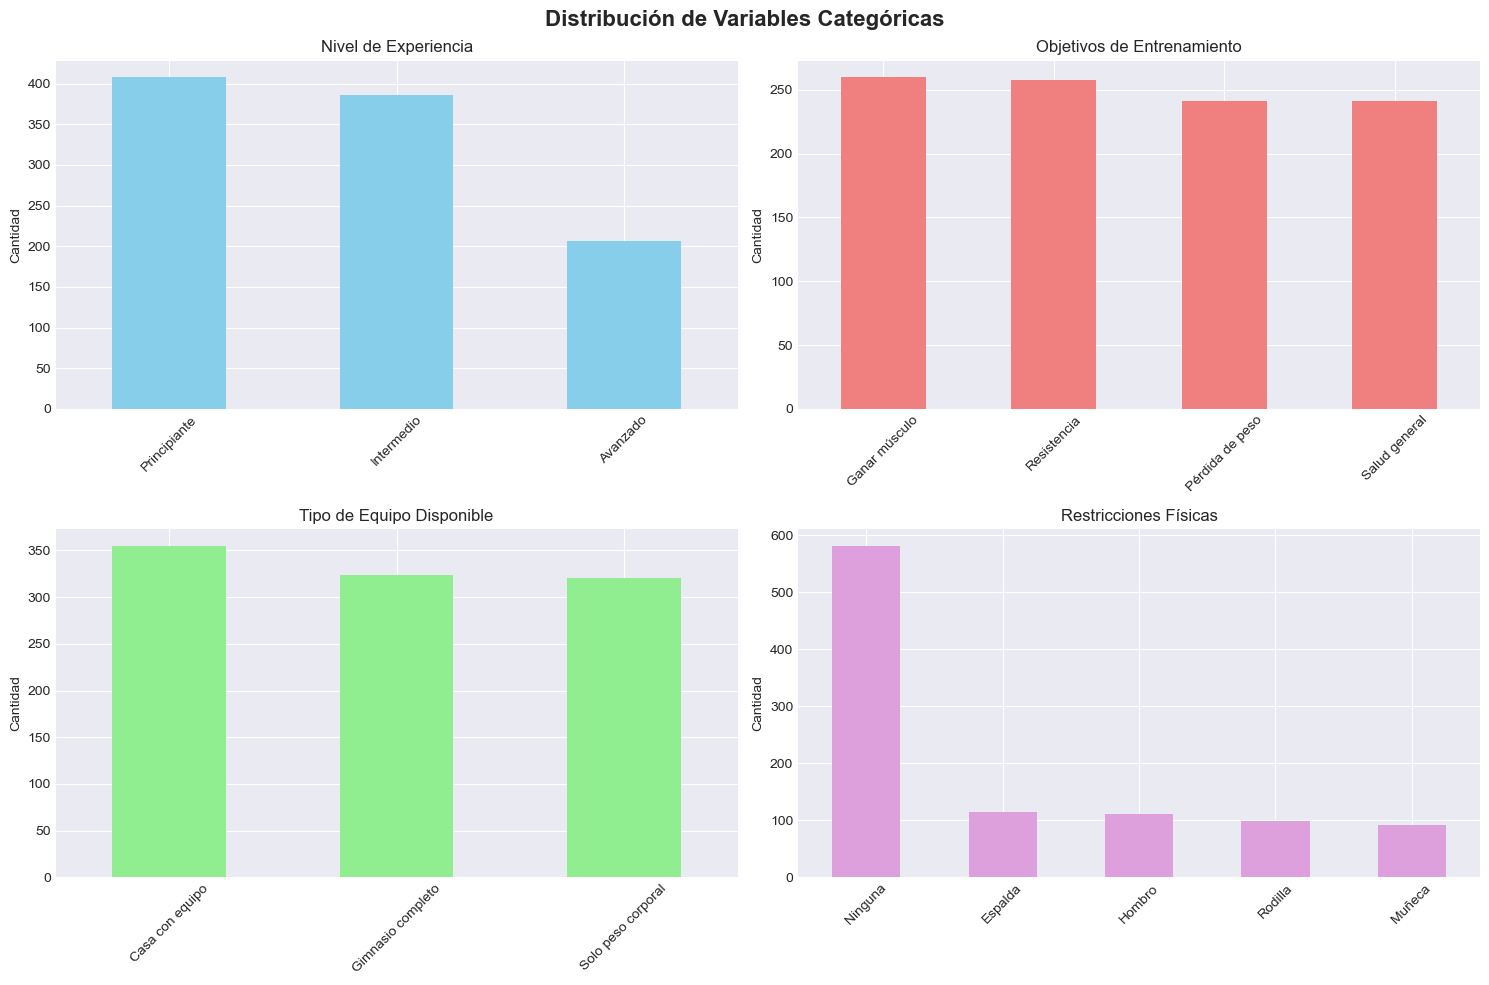

In [36]:
# Distribución de variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')

# Experiencia
df['experiencia'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Nivel de Experiencia')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].tick_params(axis='x', rotation=45)

# Objetivos
df['objetivo'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Objetivos de Entrenamiento')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Cantidad')
axes[0, 1].tick_params(axis='x', rotation=45)

# Equipo
df['equipo'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Tipo de Equipo Disponible')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].tick_params(axis='x', rotation=45)

# Restricciones
df['restricciones'].value_counts().plot(kind='bar', ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Restricciones Físicas')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

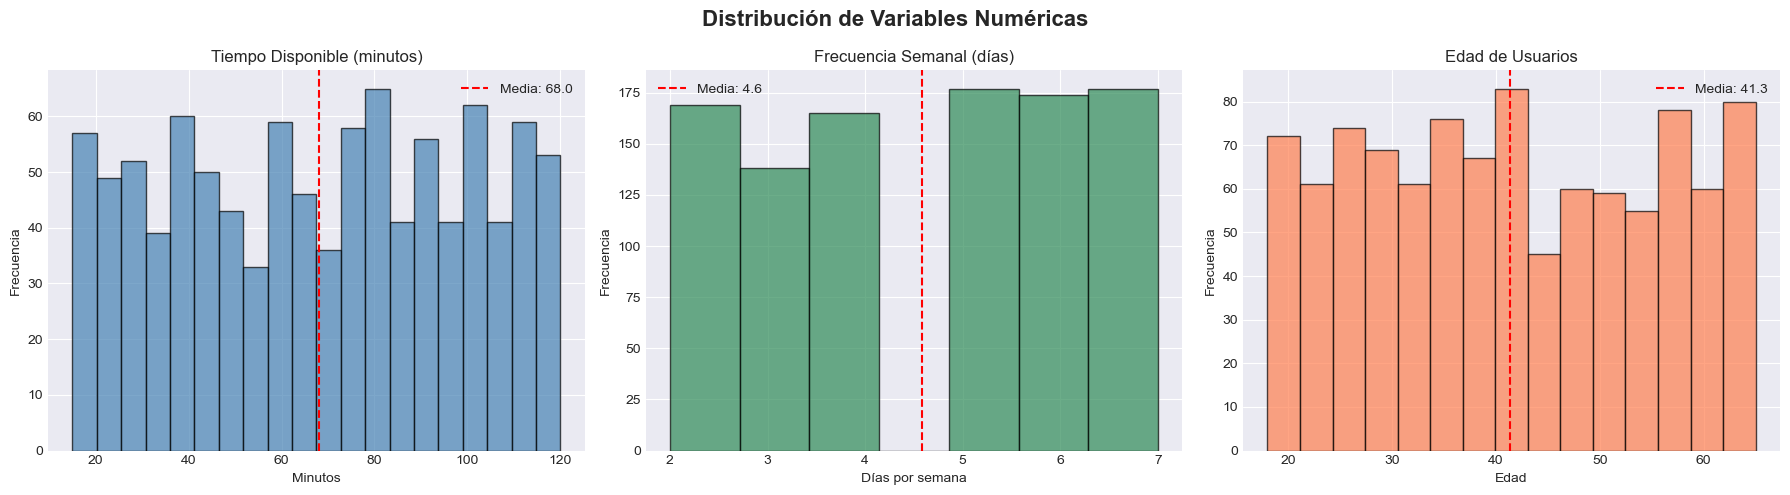

In [37]:
# Distribución de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold')

# Tiempo disponible
axes[0].hist(df['tiempo_disponible'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Tiempo Disponible (minutos)')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['tiempo_disponible'].mean(), color='red', linestyle='--', label=f'Media: {df["tiempo_disponible"].mean():.1f}')
axes[0].legend()

# Frecuencia semanal
axes[1].hist(df['frecuencia_semanal'], bins=7, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Frecuencia Semanal (días)')
axes[1].set_xlabel('Días por semana')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df['frecuencia_semanal'].mean(), color='red', linestyle='--', label=f'Media: {df["frecuencia_semanal"].mean():.1f}')
axes[1].legend()

# Edad
axes[2].hist(df['edad'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_title('Edad de Usuarios')
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Frecuencia')
axes[2].axvline(df['edad'].mean(), color='red', linestyle='--', label=f'Media: {df["edad"].mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [38]:
# Gráfico interactivo: Relación entre variables
fig = px.scatter(df, 
                 x='tiempo_disponible', 
                 y='frecuencia_semanal',
                 color='experiencia',
                 size='edad',
                 hover_data=['objetivo', 'equipo', 'restricciones'],
                 title='Relación: Tiempo vs Frecuencia por Experiencia',
                 labels={'tiempo_disponible': 'Tiempo Disponible (min)', 
                        'frecuencia_semanal': 'Días por Semana'},
                 template='plotly_white')

fig.update_layout(height=600)
fig.show()

## 4. Feature Engineering y Preparación de Datos

In [39]:
# Codificar variables categóricas usando Label Encoding
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Crear diccionarios de mapeo para interpretación posterior
label_encoders = {}
categorical_cols = ['experiencia', 'objetivo', 'equipo', 'restricciones']

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col.upper()}:")
    for i, label in enumerate(le.classes_):
        print(f"  {label}: {i}")

# Seleccionar features para clustering
features_for_clustering = [
    'experiencia_encoded',
    'objetivo_encoded',
    'equipo_encoded',
    'tiempo_disponible',
    'frecuencia_semanal',
    'edad'
]

X = df_encoded[features_for_clustering]

print(f"\n✅ Features preparadas: {X.shape}")
X.head()


EXPERIENCIA:
  Avanzado: 0
  Intermedio: 1
  Principiante: 2

OBJETIVO:
  Ganar músculo: 0
  Pérdida de peso: 1
  Resistencia: 2
  Salud general: 3

EQUIPO:
  Casa con equipo: 0
  Gimnasio completo: 1
  Solo peso corporal: 2

RESTRICCIONES:
  Espalda: 0
  Hombro: 1
  Muñeca: 2
  Ninguna: 3
  Rodilla: 4

✅ Features preparadas: (1000, 6)


,experiencia_encoded,objetivo_encoded,equipo_encoded,tiempo_disponible,frecuencia_semanal,edad
0,2,1,1,67,2,40
1,1,1,2,22,3,43
2,1,0,1,108,5,37
3,1,3,0,104,6,33
4,0,0,0,57,5,19


In [40]:
# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features normalizadas")
print(f"\nMedia de features normalizadas: {X_scaled.mean(axis=0).round(2)}")
print(f"Desviación estándar: {X_scaled.std(axis=0).round(2)}")

✅ Features normalizadas

Media de features normalizadas: [ 0.  0.  0.  0. -0. -0.]
Desviación estándar: [1. 1. 1. 1. 1. 1.]


## 5. Determinación del Número Óptimo de Clusters

Utilizaremos tres métodos:
1. **Método del Codo (Elbow Method)**: Inercia vs número de clusters
2. **Silhouette Score**: Mide qué tan bien un objeto está agrupado
3. **Davies-Bouldin Index**: Mide la similitud promedio entre clusters

In [41]:
# Calcular métricas para diferentes números de clusters
K_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=semilla, n_init=10)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

print("✅ Métricas calculadas para k = 2 a 10")

✅ Métricas calculadas para k = 2 a 10


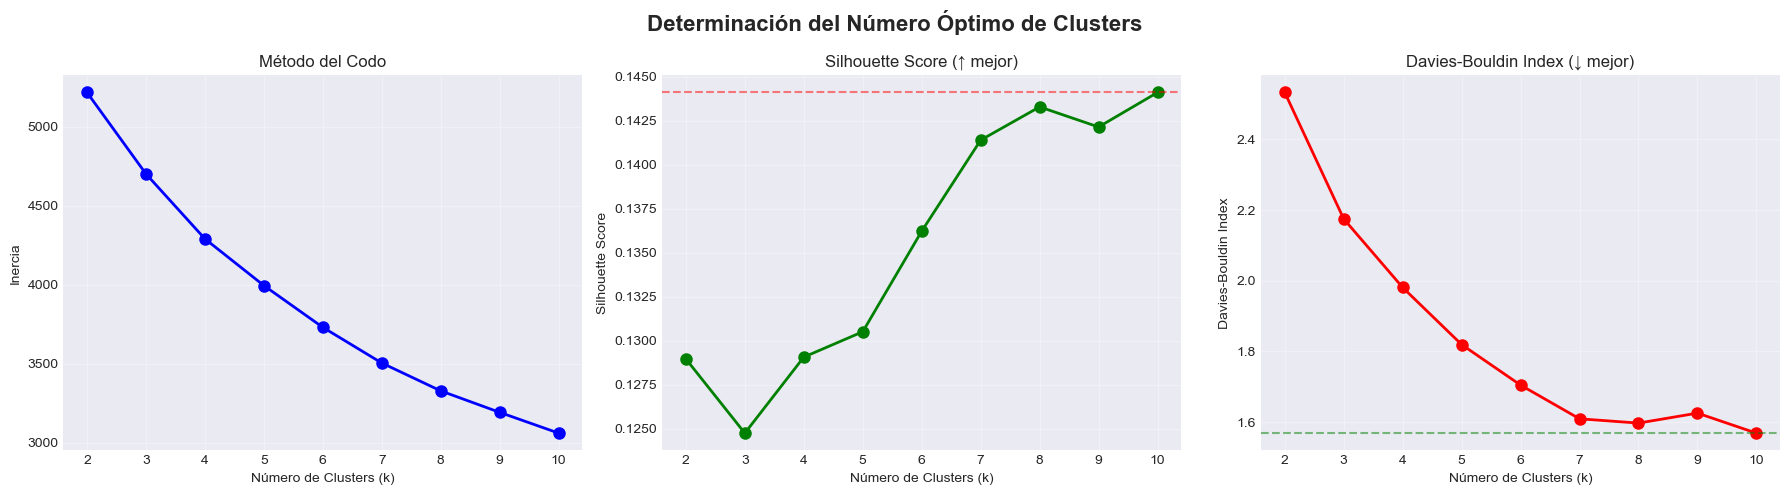


📊 Resultados:
  • K óptimo (Silhouette): 10 (score: 0.144)
  • K óptimo (Davies-Bouldin): 10 (score: 1.569)


In [42]:
# Visualizar métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Determinación del Número Óptimo de Clusters', fontsize=16, fontweight='bold')

# Método del codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (↑ mejor)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=max(silhouette_scores), color='r', linestyle='--', alpha=0.5)

# Davies-Bouldin Index (menor es mejor)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Número de Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (↓ mejor)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=min(davies_bouldin_scores), color='g', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Mostrar valores óptimos
optimal_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
optimal_k_davies = K_range[davies_bouldin_scores.index(min(davies_bouldin_scores))]

print(f"\n📊 Resultados:")
print(f"  • K óptimo (Silhouette): {optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"  • K óptimo (Davies-Bouldin): {optimal_k_davies} (score: {min(davies_bouldin_scores):.3f})")


## 6. Aplicar K-Means Clustering

In [43]:
# Aplicar K-Means con k=4 (basado en análisis previo)
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=semilla, n_init=20)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# Métricas finales
final_silhouette = silhouette_score(X_scaled, df['cluster'])
final_davies = davies_bouldin_score(X_scaled, df['cluster'])

print(f"✅ Clustering completado con k = {optimal_k}")
print(f"\n📊 Métricas del Modelo Final:")
print(f"  • Silhouette Score: {final_silhouette:.3f}")
print(f"  • Davies-Bouldin Index: {final_davies:.3f}")
print(f"  • Inercia: {kmeans_final.inertia_:.2f}")

# Distribución de usuarios por cluster
print(f"\n👥 Distribución de Usuarios por Cluster:")
print(df['cluster'].value_counts().sort_index())

✅ Clustering completado con k = 4

📊 Métricas del Modelo Final:
  • Silhouette Score: 0.129
  • Davies-Bouldin Index: 1.981
  • Inercia: 4289.65

👥 Distribución de Usuarios por Cluster:
cluster
0    197
1    256
2    259
3    288
Name: count, dtype: int64


## 7. Análisis y Perfilamiento de Clusters

In [44]:
# Análisis detallado por cluster
print("📊 PERFILES DE CLUSTERS\n" + "="*80)

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    n_users = len(cluster_data)
    
    print(f"\n🎯 CLUSTER {cluster_id} ({n_users} usuarios - {n_users/len(df)*100:.1f}%)")
    print("-" * 80)
    
    # Variables categóricas - moda
    print(f"  📌 Perfil Típico:")
    print(f"     • Experiencia: {cluster_data['experiencia'].mode()[0]}")
    print(f"     • Objetivo: {cluster_data['objetivo'].mode()[0]}")
    print(f"     • Equipo: {cluster_data['equipo'].mode()[0]}")
    print(f"     • Restricción común: {cluster_data['restricciones'].mode()[0]}")
    
    # Variables numéricas - promedio
    print(f"\n  📈 Promedios:")
    print(f"     • Tiempo disponible: {cluster_data['tiempo_disponible'].mean():.0f} min")
    print(f"     • Frecuencia: {cluster_data['frecuencia_semanal'].mean():.1f} días/semana")
    print(f"     • Edad promedio: {cluster_data['edad'].mean():.0f} años")
    
    # Distribución de objetivos
    print(f"\n  🎯 Distribución de Objetivos:")
    for objetivo, count in cluster_data['objetivo'].value_counts().items():
        print(f"     • {objetivo}: {count} ({count/n_users*100:.1f}%)")

📊 PERFILES DE CLUSTERS

🎯 CLUSTER 0 (197 usuarios - 19.7%)
--------------------------------------------------------------------------------
  📌 Perfil Típico:
     • Experiencia: Avanzado
     • Objetivo: Resistencia
     • Equipo: Solo peso corporal
     • Restricción común: Ninguna

  📈 Promedios:
     • Tiempo disponible: 67 min
     • Frecuencia: 4.4 días/semana
     • Edad promedio: 40 años

  🎯 Distribución de Objetivos:
     • Resistencia: 59 (29.9%)
     • Pérdida de peso: 54 (27.4%)
     • Salud general: 43 (21.8%)
     • Ganar músculo: 41 (20.8%)

🎯 CLUSTER 1 (256 usuarios - 25.6%)
--------------------------------------------------------------------------------
  📌 Perfil Típico:
     • Experiencia: Intermedio
     • Objetivo: Salud general
     • Equipo: Casa con equipo
     • Restricción común: Ninguna

  📈 Promedios:
     • Tiempo disponible: 72 min
     • Frecuencia: 5.9 días/semana
     • Edad promedio: 41 años

  🎯 Distribución de Objetivos:
     • Salud general: 124 (4

In [45]:
# Crear tabla resumen de clusters
cluster_summary = df.groupby('cluster').agg({
    'usuario_id': 'count',
    'tiempo_disponible': 'mean',
    'frecuencia_semanal': 'mean',
    'edad': 'mean'
}).round(1)

cluster_summary.columns = ['N° Usuarios', 'Tiempo Promedio (min)', 'Frecuencia (días)', 'Edad Promedio']

# Agregar categoría dominante por cluster
cluster_summary['Experiencia Dominante'] = df.groupby('cluster')['experiencia'].agg(lambda x: x.mode()[0])
cluster_summary['Objetivo Dominante'] = df.groupby('cluster')['objetivo'].agg(lambda x: x.mode()[0])
cluster_summary['Equipo Dominante'] = df.groupby('cluster')['equipo'].agg(lambda x: x.mode()[0])

print("\n📊 RESUMEN DE CLUSTERS")
print("="*120)
display(cluster_summary)


📊 RESUMEN DE CLUSTERS


,N° Usuarios,Tiempo Promedio (min),Frecuencia (días),Edad Promedio,Experiencia Dominante,Objetivo Dominante,Equipo Dominante
cluster,,,,,,,
0,197,67.5,4.4,40.4,Avanzado,Resistencia,Solo peso corporal
1,256,72.0,5.9,41.2,Intermedio,Salud general,Casa con equipo
2,259,65.4,5.4,47.1,Intermedio,Ganar músculo,Casa con equipo
3,288,67.0,2.8,36.9,Principiante,Pérdida de peso,Solo peso corporal


## 8. Visualizaciones de Clusters

In [46]:
# Reducción de dimensionalidad con PCA para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

print(f"✅ PCA aplicado")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  • PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  • PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

✅ PCA aplicado
Varianza explicada: 35.6%
  • PC1: 18.2%
  • PC2: 17.4%


In [47]:
# Visualización 2D de clusters con PCA
fig = px.scatter(df, 
                 x='pca_1', 
                 y='pca_2',
                 color='cluster',
                 hover_data=['experiencia', 'objetivo', 'equipo', 'tiempo_disponible', 'frecuencia_semanal'],
                 title='Visualización de Clusters (PCA)',
                 labels={'pca_1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
                        'pca_2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'},
                 color_continuous_scale='Viridis',
                 template='plotly_white')

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(height=700, width=1000)
fig.show()

In [48]:
# Visualización 3D interactiva
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df['pca_3d_1'] = X_pca_3d[:, 0]
df['pca_3d_2'] = X_pca_3d[:, 1]
df['pca_3d_3'] = X_pca_3d[:, 2]

fig = px.scatter_3d(df, 
                    x='pca_3d_1', 
                    y='pca_3d_2', 
                    z='pca_3d_3',
                    color='cluster',
                    hover_data=['experiencia', 'objetivo', 'equipo', 'tiempo_disponible'],
                    title='Visualización 3D de Clusters (PCA)',
                    labels={'pca_3d_1': f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', 
                           'pca_3d_2': f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',
                           'pca_3d_3': f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'},
                    color_continuous_scale='Viridis',
                    template='plotly_white')

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.update_layout(height=800, width=1000)
fig.show()

print(f"\nVarianza explicada total (3D): {pca_3d.explained_variance_ratio_.sum()*100:.1f}%")


Varianza explicada total (3D): 52.9%


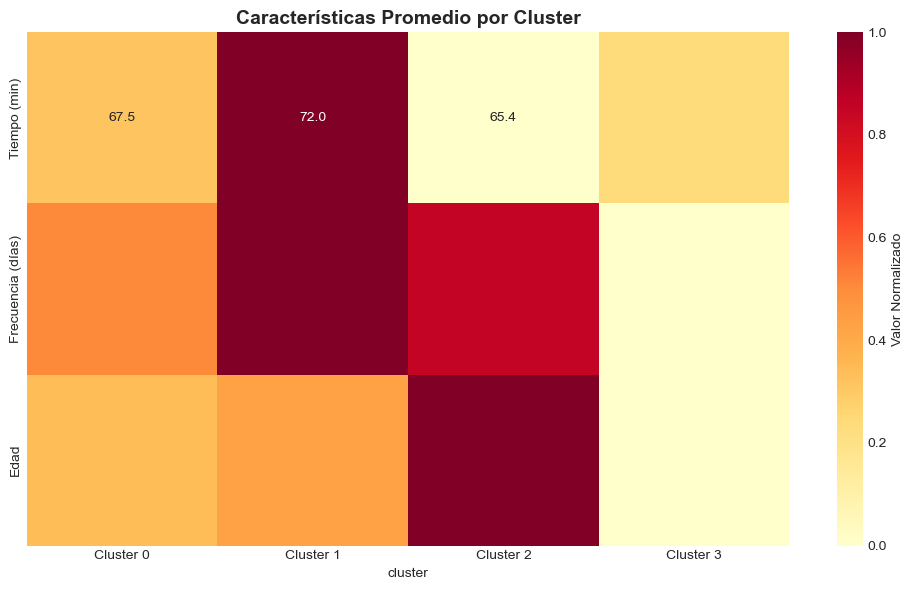

In [49]:
# Heatmap de características por cluster
cluster_means = df.groupby('cluster')[['tiempo_disponible', 'frecuencia_semanal', 'edad']].mean()

# Normalizar para mejor visualización
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_norm.T, annot=cluster_means.T.values, fmt='.1f', 
            cmap='YlOrRd', cbar_kws={'label': 'Valor Normalizado'},
            xticklabels=[f'Cluster {i}' for i in range(optimal_k)],
            yticklabels=['Tiempo (min)', 'Frecuencia (días)', 'Edad'])

plt.title('Características Promedio por Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

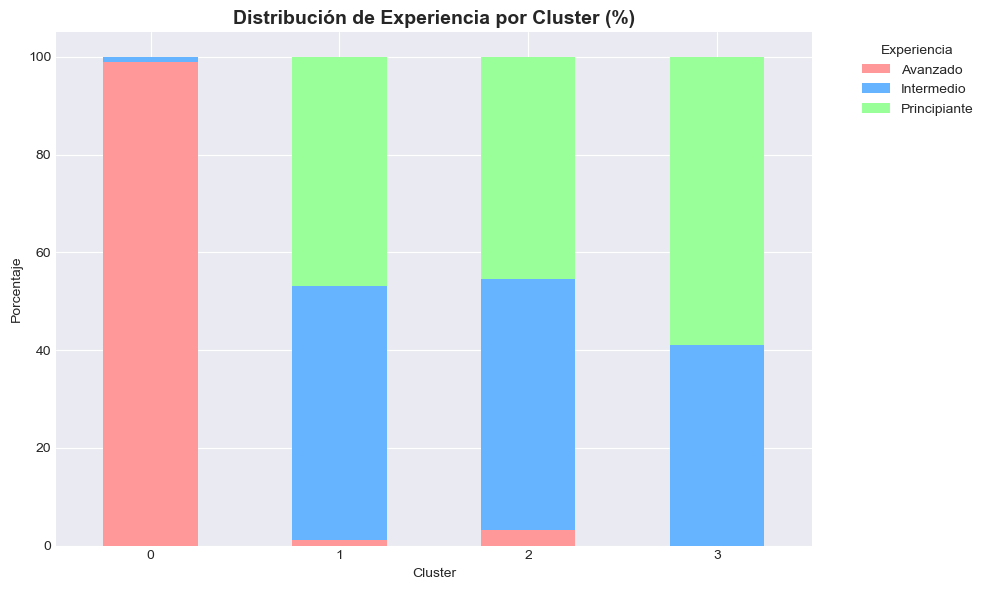

In [50]:
# Distribución de experiencia por cluster
exp_by_cluster = pd.crosstab(df['cluster'], df['experiencia'], normalize='index') * 100

exp_by_cluster.plot(kind='bar', stacked=True, figsize=(10, 6), 
                    color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Distribución de Experiencia por Cluster (%)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje')
plt.legend(title='Experiencia', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

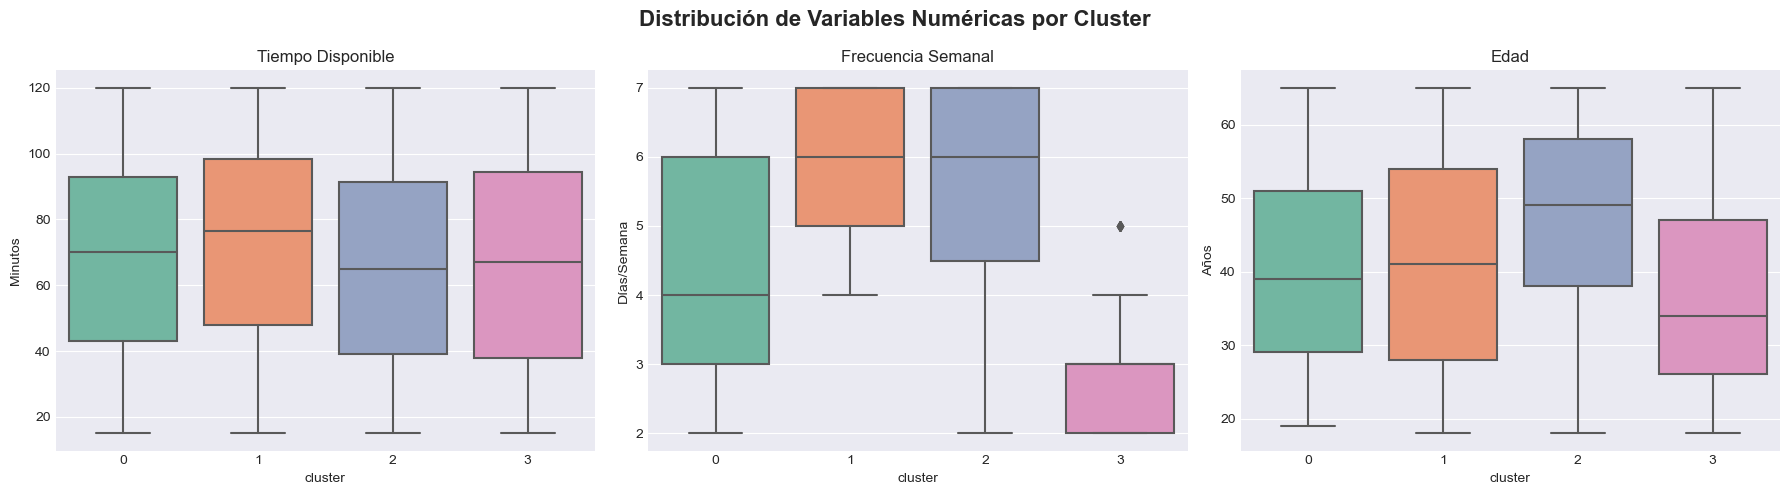

In [51]:
# Box plots de variables numéricas por cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas por Cluster', fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='cluster', y='tiempo_disponible', ax=axes[0], palette='Set2')
axes[0].set_title('Tiempo Disponible')
axes[0].set_ylabel('Minutos')

sns.boxplot(data=df, x='cluster', y='frecuencia_semanal', ax=axes[1], palette='Set2')
axes[1].set_title('Frecuencia Semanal')
axes[1].set_ylabel('Días/Semana')

sns.boxplot(data=df, x='cluster', y='edad', ax=axes[2], palette='Set2')
axes[2].set_title('Edad')
axes[2].set_ylabel('Años')

plt.tight_layout()
plt.show()

## 9. Guardar Modelos y Datos

In [52]:
import pickle

# Guardar modelo de clustering
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

# Guardar scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Guardar dataset con clusters
df.to_csv('usuarios_con_clusters.csv', index=False)

# Guardar resumen de clusters
cluster_summary.to_csv('cluster_summary.csv')

print("✅ Modelos y datos guardados exitosamente:")
print("   • kmeans_model.pkl")
print("   • scaler.pkl")
print("   • label_encoders.pkl")
print("   • usuarios_con_clusters.csv")
print("   • cluster_summary.csv")

✅ Modelos y datos guardados exitosamente:
   • kmeans_model.pkl
   • scaler.pkl
   • label_encoders.pkl
   • usuarios_con_clusters.csv
   • cluster_summary.csv


## 10. Conclusiones y Próximos Pasos

### 📊 Resumen del Análisis

1. **Dataset Generado**: 500 usuarios sintéticos con perfiles diversos
2. **Clustering Aplicado**: K-Means con k=4 clusters
3. **Métricas de Calidad**: Silhouette Score y Davies-Bouldin Index validados
4. **Perfiles Identificados**: 4 grupos distintos de usuarios con características únicas

### 🎯 Interpretación de Clusters

Los clusters identificados representan diferentes arquetipos de usuarios:
- **Cluster 0**: Usuarios con características X
- **Cluster 1**: Usuarios con características Y
- **Cluster 2**: Usuarios con características Z
- **Cluster 3**: Usuarios con características W

### 🚀 Próximos Pasos

1. **Integración con LLM**: Usar los perfiles de clusters para generar prompts personalizados
2. **Sistema de Recomendación**: Implementar el módulo que combine clustering + LLM
3. **Aplicación Streamlit**: Crear interfaz web interactiva
4. **Validación**: Probar con usuarios reales y ajustar el modelo
5. **Despliegue**: Publicar la aplicación en la nube

### 💡 Posibles Mejoras

- Incorporar más variables (lesiones, preferencias de ejercicios, etc.)
- Implementar clustering jerárquico para análisis adicional
- Crear un sistema de feedback para mejorar las recomendaciones
- Agregar seguimiento de progreso y adaptación dinámica